In [5]:
import os
os.environ["PATH"] = "/data/apps/extern/spack_on/gcc/9.3.0/texlive/20220321-oikenzl6gekq5lsohdm6jnnuj276s2ba/bin/x86_64-linux:" + os.environ.get("PATH", "")

import sys
from pathlib import Path

this_notebook = Path().resolve()

project_root = this_notebook.parents[0]

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

## Module imports

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LogNorm, SymLogNorm

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

#import Zeus
import zeus21

#set up the CLASS cosmology
from classy import Class
import mcfit
from scipy.interpolate import interp1d

## Get high-res $\rho$'s using memory-friendly method

In [7]:
UserParams = zeus21.User_Parameters(precisionboost=1.2)

# cosmo inputs from table 2 last column of 1807.06209, as 21cmFAST
ombh2 = 0.02242 
omch2 = 0.11933
tau_re = 0.0544
hLittle = 0.6766
ns = 0.9665
As = np.exp(3.047)*10**(-10.)

CosmoParams_input = zeus21.Cosmo_Parameters_Input(
    omegac = omch2, omegab = ombh2, h_fid = hLittle, As = As, ns = ns, tau_fid = tau_re, 
    USE_RELATIVE_VELOCITIES = True, Flag_emulate_21cmfast=False,
    ANISO_XI_ETA = False
    )

ClassCosmoVCB = Class()
ClassCosmoVCB.set({'omega_b': CosmoParams_input.omegab,
                   'omega_cdm': CosmoParams_input.omegac,
                   'h': CosmoParams_input.h_fid,
                   'A_s': CosmoParams_input.As,
                   'n_s': CosmoParams_input.ns,
                   'tau_reio': CosmoParams_input.tau_fid})
ClassCosmoVCB.set({'output':'vTk'})
ClassCosmoVCB.set({'P_k_max_1/Mpc':50.0, 'z_max_pk':12000})
ClassCosmoVCB.set({'gauge':'newtonian'})
ClassCosmoVCB.compute()

# Cosmo_Parameters = zeus21.Cosmo_Parameters(UserParams, CosmoParams_input, ClassyCosmo) 

In [8]:
from scipy.interpolate import interp1d

rlist = np.geomspace(0.1, 3000, 300)
klist, _dummy_ = mcfit.xi2P(rlist, l=0, lowring=True)(0*rlist, extrap=False)

# kmask = (klist >= 1e-3) & (klist <= 1.0)
# klist_trim = klist[kmask]
# Plist_trim = Plist[kmask]

z_drag = ClassCosmoVCB.get_current_derived_parameters(['z_d'])['z_d']
velTransFunc = ClassCosmoVCB.get_transfer(z_drag)

c_kms = 299792.458
k_vcb = velTransFunc['k (h/Mpc)'] * CosmoParams_input.h_fid
theta_b = velTransFunc['t_b']
theta_c = velTransFunc['t_cdm']
interp_func_theta_b = interp1d(k_vcb, theta_b, kind='cubic', fill_value="extrapolate")
interp_func_theta_c = interp1d(k_vcb, theta_c, kind='cubic', fill_value="extrapolate")
theta_b_dense = interp_func_theta_b(klist)
theta_c_dense = interp_func_theta_c(klist)

P_vcb = CosmoParams_input.As * (klist/0.05)**(CosmoParams_input.ns-1) * (theta_b_dense - theta_c_dense)**2/klist**2 * 2 * np.pi**2 / klist**3
sigma_vcb = np.sqrt(np.trapz(CosmoParams_input.As * (klist/0.05)**(CosmoParams_input.ns-1) / klist * (theta_b_dense - theta_c_dense)**2/klist**2, klist)) * c_kms


def Window(k,R):
        x = k * R
        return 3.0/x**2 * (np.sin(x)/x - np.cos(x))

In [9]:
# Original implementation (causes OOM)
# lengthRarray = len(rlist)
#
# windowR1 = Window(klist.reshape(lengthRarray, 1, 1), rlist.reshape(1, 1, lengthRarray))
# windowR2 = Window(klist.reshape(1, lengthRarray,1), rlist.reshape(1, 1, lengthRarray))
#
# psi_integrand_base = klist**2 / 2 / np.pi**2 * P_vcb * windowR1 * windowR2
# psi_integrand_base = psi_integrand_base[:, :, np.newaxis, :]
#
# psi_prefactor = 1 / (3 * (sigma_vcb/c_kms)**2)
#
# r_transpose = np.transpose([rlist])
# j0bessel = lambda x: np.sin(x)/x
# j2bessel = lambda x: (3 / x**2 - 1) * np.sin(x)/x - 3*np.cos(x)/x**2
#
# psi0 = 1 * psi_prefactor * np.trapz(psi_integrand_base * j0bessel(klist * r_transpose)[np.newaxis, np.newaxis, :, :],
#                                     klist, axis = -1)
# psi2 = -2 * psi_prefactor * np.trapz(psi_integrand_base * j2bessel(klist * r_transpose)[np.newaxis, np.newaxis, :, :],
#                                         klist, axis = -1)
#
# xi_para_RR_CF = psi0 + psi2
# xi_perp_RR_CF = psi0 - 0.5 * psi2
#
# # Normalize them
# xi_para_RR_CF /= np.max(np.abs(xi_para_RR_CF))
# xi_perp_RR_CF /= np.max(np.abs(xi_perp_RR_CF))

import gc

lengthRarray = len(rlist)

windowR1 = Window(klist.reshape(lengthRarray, 1, 1), rlist.reshape(1, 1, lengthRarray))
windowR2 = Window(klist.reshape(1, lengthRarray, 1), rlist.reshape(1, 1, lengthRarray))
psi_integrand_base = klist**2 / 2 / np.pi**2 * P_vcb * windowR1 * windowR2

psi_prefactor = 1 / (3 * (sigma_vcb / c_kms)**2)

r_transpose = np.transpose([rlist])
j0bessel = lambda x: np.sin(x) / x
j2bessel = lambda x: (3 / x**2 - 1) * np.sin(x) / x - 3 * np.cos(x) / x**2

# Trapezoid weights so each integration can be done as a weighted contraction.
dk = np.diff(klist)
trapz_w = np.empty_like(klist)
trapz_w[0] = 0.5 * dk[0]
trapz_w[-1] = 0.5 * dk[-1]
trapz_w[1:-1] = 0.5 * (klist[2:] - klist[:-2])

j0_grid = j0bessel(klist * r_transpose)
j2_grid = j2bessel(klist * r_transpose)

# Allocate only the final arrays to reduce peak memory.
xi_para_RR_CF = np.empty((lengthRarray, lengthRarray, lengthRarray), dtype=np.float64)
xi_perp_RR_CF = np.empty_like(xi_para_RR_CF)

for ir in range(lengthRarray):
    w0 = j0_grid[ir] * trapz_w
    w2 = j2_grid[ir] * trapz_w
    integ0 = psi_prefactor * np.tensordot(psi_integrand_base, w0, axes=([-1], [0]))
    integ2 = -2 * psi_prefactor * np.tensordot(psi_integrand_base, w2, axes=([-1], [0]))
    xi_para_RR_CF[:, :, ir] = integ0 + integ2
    xi_perp_RR_CF[:, :, ir] = integ0 - 0.5 * integ2

# Normalize them
xi_para_RR_CF /= np.max(np.abs(xi_para_RR_CF))
xi_perp_RR_CF /= np.max(np.abs(xi_perp_RR_CF))

# Drop large temporaries before moving to later cells to avoid kernel OOM.
del windowR1, windowR2, psi_integrand_base, dk, trapz_w, j0_grid, j2_grid
gc.collect()

0

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


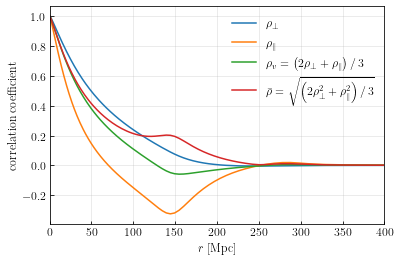

In [10]:
R1_choose = 0
R2_choose = 0

rho_para = xi_para_RR_CF[R1_choose, R2_choose, :]
rho_perp = xi_perp_RR_CF[R1_choose, R2_choose, :]
rho_orig = np.sqrt((2 * xi_perp_RR_CF[R1_choose, R2_choose, :]**2 + \
                   xi_para_RR_CF[R1_choose, R2_choose, :]**2) / 3)
rho_iso = (2 * rho_perp + rho_para) / 3

fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(rlist, rho_perp, label=r'$\rho_{\perp}$')
ax.plot(rlist, rho_para, label=r'$\rho_{\parallel}$')
ax.plot(rlist, rho_iso, label=r'$\rho_v=\left(2\rho_\perp + \rho_\parallel\right)/\,3$')
ax.plot(rlist, rho_orig, label=r'$\bar\rho=\sqrt{\left(2\rho_{\perp}^2 + \rho_{\parallel}^2\right)/\,3}$')

ax.set_xlim(0, 400)
ax.set_xlabel(r'$r$ [Mpc]')
ax.set_ylabel(r'correlation coefficient')
ax.legend(frameon=False)
ax.tick_params(axis='both', which='major', direction='in')
ax.grid(True, which='both', alpha=0.3)

## Use these $\rho$'s to compute $\xi_U$

In [11]:
# Real run values from xi_U_comparison.ipynb
lambda1 = 1.1819690031628485
lambda2 = 1.1819690031628485

rho_para = xi_para_RR_CF
rho_perp = xi_perp_RR_CF

lambda_term = 4 * lambda1 * lambda2 / (1 + 2 * lambda1) / (1 + 2 * lambda2)
xi_U_highres = ((1 - lambda_term * rho_para**2) * (1 - lambda_term * rho_perp**2) ** 2) ** (-1/2) - 1
xi_U_highres_normalized = xi_U_highres / xi_U_highres.max()

### Compare with low-res versions

First retrieve the $\xi_U$'s computed in `xi_U_comparison.ipynb`:

In [12]:
import gc
from pathlib import Path

# Run a collection before loading additional arrays; this cell often follows large 3D allocations.
gc.collect()

candidate_files = [
    Path("output/xi_U_normalized_data.npz"),
    project_root / "aniso_tests" / "output" / "xi_U_normalized_data.npz",
]

for data_file in candidate_files:
    if data_file.exists():
        break
else:
    raise FileNotFoundError(
        "Could not find xi_U_normalized_data.npz in ./output or project_root/aniso_tests/output"
    )

saved = np.load(data_file)
r_saved = saved["rlist"]
xi_U_zeus_saved = saved["xi_U_zeus_normalized"]
xi_U_aniso_saved = saved["xi_U_aniso_normalized"]
xi_U_corrected_saved = saved["xi_U_corrected_normalized"]
saved.close()

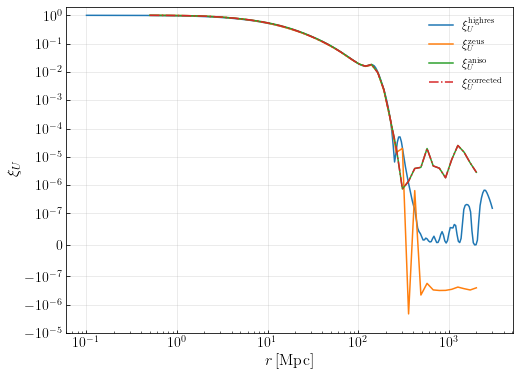

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rlist, xi_U_highres_normalized[0, 0, :], label=r'$\xi_U^{\mathrm{highres}}$')
ax.plot(r_saved, xi_U_zeus_saved, label=r"$\xi_U^{\mathrm{zeus}}$")
ax.plot(r_saved, xi_U_aniso_saved, label=r"$\xi_U^{\mathrm{aniso}}$")
ax.plot(r_saved, xi_U_corrected_saved, linestyle="-.", label=r"$\xi_U^{\mathrm{corrected}}$")
ax.set_ylim(-1e-5, 2)
ax.set_xscale("log")
ax.set_yscale('symlog', linthresh=1e-7)
ax.set_xlabel(r"$r\,[\mathrm{Mpc}]$", fontsize=16)
ax.set_ylabel(r"$\xi_U$", fontsize=16)
ax.legend(frameon=False)
ax.tick_params(axis="both", which="both", direction="in", labelsize=14)
ax.grid(True, alpha=0.3)

### Now plot high-res $\xi_U$'s with different $K$'s

In [14]:
K_values = [1/3, 2/3, 1.0]
R1_choose = 0
R2_choose = 0

def xi_U_with_K(rho_para, rho_perp, K):
    sqrt_term = (1 - K * rho_para**2) * (1 - K * rho_perp**2)**2
    return sqrt_term**(-0.5) - 1

# Use full high-resolution anisotropic rho fields.
rho_para_full = xi_para_RR_CF
rho_perp_full = xi_perp_RR_CF

# Define isotropic rho-bar from anisotropic components.
rho_bar_full = np.sqrt((2 * rho_perp_full**2 + rho_para_full**2) / 3)

xi_U_aniso_by_K = {}
xi_U_iso_by_K = {}

for K in K_values:
    xi_U_aniso_by_K[K] = xi_U_with_K(rho_para_full, rho_perp_full, K)
    xi_U_iso_by_K[K] = xi_U_with_K(rho_bar_full, rho_bar_full, K)

/home/yzhan629/Zeus21/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: divide by zero encountered in power
  import sys


/home/yzhan629/Zeus21/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:30: RuntimeWarning: invalid value encountered in subtract
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


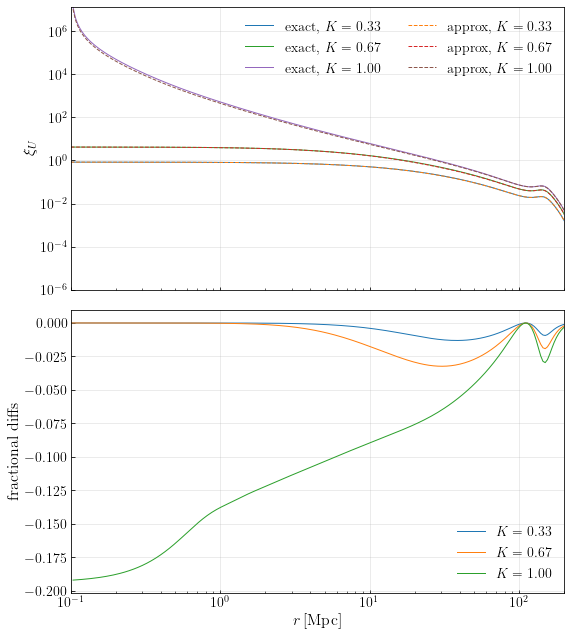

In [15]:
fig, axs = plt.subplots(
    2, 1, figsize=(8, 9), sharex=True, gridspec_kw={"height_ratios": [1, 1]}
 )

aniso_handles = []
iso_handles = []

for K in K_values:
    aniso_curve = xi_U_aniso_by_K[K][R1_choose, R2_choose, :]
    iso_curve = xi_U_iso_by_K[K][R1_choose, R2_choose, :]
    # aniso_curve = aniso_curve / np.max(aniso_curve)
    # iso_curve = iso_curve / np.max(iso_curve)

    h_aniso, = axs[0].plot(
        rlist,
        aniso_curve,
        lw=1,
        label=rf"exact, $K={K:.2f}$"
    )
    h_iso, = axs[0].plot(
        rlist,
        iso_curve,
        lw=1,
        ls="--",
        label=rf"approx, $K={K:.2f}$"
    )
    aniso_handles.append(h_aniso)
    iso_handles.append(h_iso)

    frac_diff = (iso_curve - aniso_curve) / aniso_curve
    axs[1].plot(rlist, frac_diff, lw=1, label=rf"$K={K:.2f}$")

# Column grouping: left = anisotropic, right = isotropic.
legend_handles = aniso_handles + iso_handles
legend_labels = [h.get_label() for h in legend_handles]

axs[0].set_xlim(1e-1, 200)
axs[0].set_ylim(1e-6, )
axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].set_ylabel(r"$\xi_U$", fontsize=16)
axs[0].legend(legend_handles, legend_labels, frameon=False, fontsize=14, ncol=2)
axs[0].tick_params(axis="both", which="both", direction="in", labelsize=14)
axs[0].grid(True, alpha=0.3)

axs[1].set_xscale("log")
axs[1].set_xlabel(r"$r\,[\mathrm{Mpc}]$", fontsize=16)
axs[1].set_ylabel(r"fractional diffs", fontsize=16)
axs[1].tick_params(axis="both", which="both", direction="in", labelsize=14)
axs[1].grid(True, alpha=0.3)
axs[1].legend(frameon=False, fontsize=14)

plt.tight_layout()